# European Marine Heatwave Analysis

By [Ben Welsh](https://palewi.re/who-is-ben-welsh/)

This repository contains data and code supporting a Reuters analysis of European sea-surface temperatures in summer 2026.

Published September 26, 2026: ["Europe's seas are breaking heat records. Its fisheries are paying the price."](https://www.reuters.com/world/europe/how-europes-intensifying-marine-heatwaves-threaten-its-fisheries-2026-09-26/)

The key findings of the data analysis are:

1)  “European waters notched their hottest summer months since satellite sensors began providing reliable data in 1982, according to a Reuters analysis of temperatures recorded at the seas’ surface.”

2)  “Records fell from the English Channel to the Mediterranean Sea.”

3)  "Taken together, European seas averaged 21.6 C (70.9 F) between June and August, the highest in 45 years of available data."

4)  “Few areas strayed further from the norm this summer than the Bay of Biscay, off the Atlantic-facing coast of France and Spain.”

5) "The bay's traditionally cool waters averaged 21.4 C (70.5 F) between June and August, more than 2.4 degrees (4.4 degrees) above the 1991-2020 average. Readings from the U.S. National Oceanic and Atmospheric Administration peaked on August 13 at 23.2 C (74 F), the highest of the satellite era."

6) "In the 1980s, the Bay of Biscay averaged a handful of heatwave days per year. By the end of August, it had logged 186 this year, more than three out of every four days."

7) "Since 2022, the English Channel has been under heatwave conditions for around six months out of the year on average, logging more than 900 days in all."

The analysis is based on data compiled by the [U.S. National Oceanic and Atmospheric Administration](https://www.ncei.noaa.gov/products/optimum-interpolation-sst) and the [European Union's Copernicus Climate Change Service](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview). The two organizations publish average temperatures across a global grid with a resolution of 0.25 degrees of latitude and longitude per cell, based on readings gathered by buoys, ships, satellite sensors and other sources.

The data was downloaded from the public data portals maintained by each agency and stored in a local directory that is excluded from this repository. The NOAA data is drawn from the [Optimum Interpolation Sea Surface Temperature (OISST) dataset](https://www.ncei.noaa.gov/products/optimum-interpolation-sst) archive at [www.ncei.noaa.gov](https://www.ncei.noaa.gov/data/sea-surface-temperature-optimum-interpolation/v2.1/access/avhrr). The Copernicus data is drawn from the [ERA5 reanalysis dataset](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview) archive at [cds.climate.copernicus.eu](https://cds.climate.copernicus.eu/api/catalogue/v1/collections/reanalysis-era5-single-levels/).

Reuters defined European waters as a combination of six marine regions [identified by the European Environment Agency](https://www.eea.europa.eu/en/analysis/maps-and-charts/marine-regions-and-subregions), which do not include Arctic areas or Macaronesia. Boundaries for the Bay of Biscay, the English Channel and other seas were taken from the [International Hydrographic Organization](https://iho.int/uploads/user/pubs/standards/s-23/S-23_Ed3_1953_EN.pdf).

This notebook calculates the average temperatures across those areas in June, July and August for each year since 1982, when satellite-based observations began providing reliable data. Values are area-weighted to account for the varying size of grid cells at different latitudes. While results varied slightly, the summer of 2026 had the highest European averages in both datasets.

Marine heatwaves were defined using [the Hobday method](https://www.sciencedirect.com/science/article/abs/pii/S0079661116000057) adopted by most scientists and major climate research organizations. Each daily reading was compared against a 1991-2020 baseline and judged to be in a heatwave when it surpassed the 90th percentile for five-or-more consecutive days. This portion of the analysis was done exclusively with the NOAA dataset.



## Configuration 

Import Python tools and set environment variables

In [102]:
import contextlib
import io
import warnings
from datetime import datetime, date
from pathlib import Path
from typing import cast, overload

import dask
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.geoaxes import GeoAxes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from dask.diagnostics import ProgressBar
from earthkit.transforms import spatial

from xmhw.identify import add_doy
from xmhw.xmhw import threshold as xmhw_threshold

Set our dates for the analysis.

In [53]:
# The earliest date of satellite-based data in our database
START_DATE = datetime(1981, 9, 1)

# The final date of our analysis, the end of the summer season in 2026
END_DATE = datetime(2026, 8, 31)

# The full range of dates between those two points in time
FULL_DATE_RANGE= pd.date_range(START_DATE, END_DATE, freq="D")

# The subset of dates that fall within the summer months (June to August)
SUMMER_DATES = FULL_DATE_RANGE[(FULL_DATE_RANGE.month >= 6) & (FULL_DATE_RANGE.month <= 8)]

# Create a list of the first day of each unique summer month (1982-06-01, )
SUMMER_MONTHS = sorted({dt for dt in SUMMER_DATES if dt.day == 1})

# The 1991-2020 baseline period used for heatwave thresholds and anomaly comparisons
CLIMATOLOGY_START_YEAR = 1991
CLIMATOLOGY_END_YEAR = 2020

# How many threads dask should use when reading daily files concurrently.
DASK_WORKERS = 1

Set the paths to our data directories and files.

In [26]:
# This directory
THIS_DIR = Path("").parent.absolute()

# The core data directory for the analysis
DATA_DIR = Path("data")

# The cache directory for storing our source files
CACHE_DIR = DATA_DIR / "cache"

# The NOAA OISST daily data files
NOAA_FILES = sorted(CACHE_DIR.glob("oisst/**/*.nc"))

# The ERA5 monthly data files
ERA5_FILES = sorted(CACHE_DIR.glob("era5-monthly-means-europe/**/*.nc"))

Create a date-based lookup for each dataset.

In [27]:
def parse_noaa_date(path: Path) -> date:
    """Parse the date from a NOAA file path.

    Args:
        path (Path): The path to the NOAA file.

    Returns:
        date: The date extracted from the file name.
    """
    dt_str = path.name.split(".")[1]
    return datetime.strptime(dt_str, "%Y%m%d").date()

In [28]:
NOAA_LOOKUP = {parse_noaa_date(p): p for p in NOAA_FILES}

In [29]:
def parse_era5_date(path: Path) -> date:
    """Parse the date from an ERA5 file path.

    Args:
        path (Path): The path to the ERA5 file.

    Returns:
        date: The date extracted from the file name.
    """
    month_str = path.name.split(".")[1]
    return datetime.strptime(month_str, "%Y%m").date()

In [30]:
ERA5_LOOKUP = {parse_era5_date(p): p for p in ERA5_FILES}

Verify we have NOAA daily files for the full date range.

In [31]:
# The count should be the same.
assert len(NOAA_FILES) == len(FULL_DATE_RANGE)

# Every date in the full range should have a corresponding NOAA file.
assert [dt in NOAA_LOOKUP for dt in FULL_DATE_RANGE]

Verify we have ERA5 files for the full range of summer months.

In [32]:
# The count should be the same.
assert len(ERA5_FILES) == len(SUMMER_MONTHS)

# Every month in SUMMER_MONTHS should have a corresponding ERA5 file
assert [dt in ERA5_LOOKUP for dt in SUMMER_MONTHS]

Create utilities for opening the files.

In [33]:
def open_noaa_date(dt: datetime) -> xr.Dataset:
    """Read in the NOAA data file for the given date.

    Args:
        dt (datetime): The date for which to read the NOAA data file.

    Returns:
        xr.Dataset: The opened NOAA dataset for the given date.
    """
    # Pull the file pat
    path = NOAA_LOOKUP[dt.date()]

    # Open it with xarray
    return xr.open_dataset(path, engine="h5netcdf")


In [34]:
def open_era5_month(dt: datetime) -> xr.Dataset:
    """Read in the ERA5 data file for the given month.

    Args:
        dt (datetime): The month for which to read the ERA5 data file.

    Returns:
        xr.Dataset: The opened ERA5 dataset for the given month.
    """
    path = ERA5_LOOKUP[dt.date()]

    # Open it with xarray
    return xr.open_dataset(path, engine="h5netcdf")

## Mapping European seas

Our definition is the map of six large European seas as defined by the European Environment Agency. They are compressed into individual file stored in this repository.

In [35]:
EEA_REGIONS = Path("boundaries/eea_six_regions_oisst_mask.npz")

This and other files will need to be transformed from a 0-360 longitude format to a -180 to 180 longitude format to avoid clipping Europe in two pieces at the prime meridian.

In [91]:
@overload
def center_longitudes(data: xr.DataArray) -> xr.DataArray:
    ...


@overload
def center_longitudes(data: xr.Dataset) -> xr.Dataset:
    ...


def center_longitudes(
    data: xr.Dataset | xr.DataArray,
) -> xr.Dataset | xr.DataArray:
    """Transform longitudes from 0-360 to -180-180.

    Args:
        data (xr.Dataset | xr.DataArray): Input dataset or data array with longitudes in 0-360 format.

    Returns:
        xr.Dataset | xr.DataArray: Dataset or data array with longitudes transformed to -180-180 format.
    """
    centered = (data["lon"] + 180) % 360 - 180
    return data.assign_coords(lon=centered).sortby("lon")

We'll do that transform when we read in the mask and prepare it for analysis.

In [92]:
def load_europe_region_mask(path: Path) -> xr.DataArray:
    """Load and prepare the EEA European seas mask.

    Args:
        path (Path): Path to the .npz file containing the mask.

    Returns:
        xr.DataArray: The prepared European seas mask with centered longitudes and an added region dimension.
    """
    with np.load(path) as mask_archive:
        mask = xr.DataArray(
            mask_archive["mask"],
            coords={
                "lat": mask_archive["latitude"],
                "lon": mask_archive["longitude"],
            },
            dims=("lat", "lon"),
        )

    return center_longitudes(mask).expand_dims(region=["european-seas"])

In [93]:
europe_region_mask = load_europe_region_mask(EEA_REGIONS)

Let's have a look at it here.

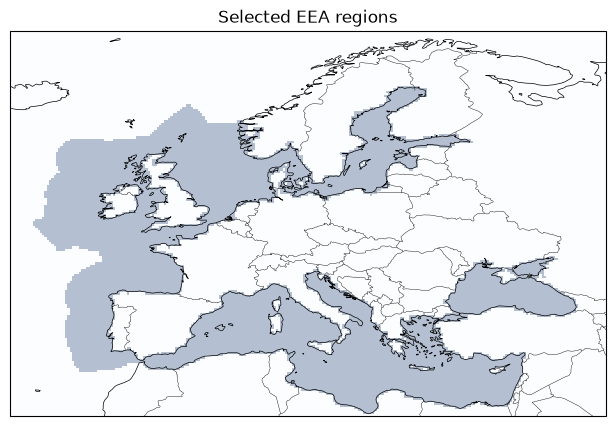

In [103]:
# Make a simple map of the selected EEA mask over real coastlines
preview_mask = europe_region_mask.squeeze("region")
figure, axis = plt.subplots(figsize=(8, 5), subplot_kw={"projection": ccrs.PlateCarree()})
axis = cast(GeoAxes, axis)
axis.pcolormesh(
    preview_mask.lon,
    preview_mask.lat,
    preview_mask,
    cmap="Blues",
    alpha=0.3,
    transform=ccrs.PlateCarree(),
)
axis.add_feature(cfeature.COASTLINE, linewidth=0.5)
axis.add_feature(cfeature.BORDERS, linewidth=0.3)

# Zoom in on Europe
axis.set_extent([-20, 45, 30, 72], crs=ccrs.PlateCarree())

# Show it
axis.set_title("Selected EEA regions")
plt.show()

## Analyzing Europe as a whole

We will want to filter down our maps to only European seas, and later IHO seas. Here's how we'll do it:

In [42]:
def apply_mask(values: xr.DataArray, valid_mask: xr.DataArray) -> xr.DataArray:
    """Filter a DataArray using a mask.

    Args:
        values (xr.DataArray): Input data array to be filtered.
        valid_mask (xr.DataArray): Boolean mask indicating valid grid cells.

    Returns:
        xr.DataArray: Filtered data array with only valid grid cells.
    """
    return values.squeeze(drop=True).where(valid_mask)

The gridded data will need to be averaged over the map while accounting for the fact that grid cells represent different areas depending on their latitude. This is called area weighting. We'll use the open-source implementation published by Copernicus in [earthkit](https://earthkit.ecmwf.int/).

In [43]:
def area_weighted_reduce(values: xr.DataArray) -> xr.DataArray:
    """Average data over the map using latitude-based area weighting.

    Uses the earthkit method developed by ECMWF.

    Args:
        values (xr.DataArray): Input data array to be averaged.

    Returns:
        xr.DataArray: Area-weighted average of the input data array.
    """
    return spatial.reduce(values, how="mean", weights="latitude").squeeze(drop=True)

When analyzing gridded data, we need to exclude grid cells that are on land or covered with ice. Here's how we do that with the NOAA data.

In [44]:
# Areas with ice will be excluded, as in standard in oceanographic science.
def valid_noaa_ocean(sst: np.ndarray, ice: np.ndarray) -> np.ndarray:
    """Determine which ocean grid cells are ice-free and have valid sea-surface temperature.

    Args:
        sst (np.ndarray): Sea-surface temperature array.
        ice (np.ndarray): Sea-ice concentration array.

    Returns:
        np.ndarray: Boolean array indicating which grid cells are ice-free and have valid sea-surface temperature.
    """
    # Make sure the input arrays have the same shape.
    if sst.shape != ice.shape:
        raise ValueError("sst and ice must have the same shape")

    # Determine which grid cells are ice-free and have valid sea-surface temperature.
    return ~np.isnan(sst) & np.isnan(ice)

Now we bring it all together by filtering each day's data to sea temperatures inside European waters before generating a area-weighted average. This function is written to support any regional mask, not just Europe.

In [55]:
def reduce_noaa_regions_date(
    observation_date: datetime,
    region_masks: xr.DataArray,
) -> pd.DataFrame:
    """Reduce NOAA data to area-weighted mean sea-surface temperature for each region on a given date.

    Args:
        observation_date (datetime): The date for which to reduce the NOAA data.
        region_masks (xr.DataArray): A DataArray containing the regional masks.

    Returns:
        pd.DataFrame: A DataFrame with one row per region, containing the area-weighted mean sea-surface temperature and cell counts for each region.
    """
    # Open the day's NOAA file.
    with open_noaa_date(observation_date) as dataset:
        # Flip its longitude to -180-180 so it matches the region masks.
        centered = center_longitudes(dataset)

        # Pull the SST field, cropped to the mask's grid.
        sst = centered["sst"].squeeze(drop=True).sel(
            lat=region_masks["lat"],
            lon=region_masks["lon"],
        )

        # Pull the ice field, cropped to the same grid.
        ice = centered["ice"].squeeze(drop=True).sel(
            lat=region_masks["lat"],
            lon=region_masks["lon"],
        )

        # Flag which cells are ice-free and have a valid SST reading.
        ocean_mask = xr.DataArray(
            valid_noaa_ocean(sst.values, ice.values),
            coords=sst.coords,
            dims=sst.dims,
        )

        # Step 1: restrict to the selected region(s).
        region_sst = apply_mask(sst, region_masks)

        # Step 2: restrict further to valid ocean cells.
        valid_sst = apply_mask(region_sst, ocean_mask)

        # Step 3: reduce each region to one area-weighted mean.
        means = spatial.reduce(
            valid_sst,
            how="mean",
            weights="latitude",
            mask_dim="region",
        )

        # Count every cell in each region, valid or not.
        region_cells = region_masks.sum(dim=("lat", "lon"))

        # Count the cells that made it through both masking steps.
        valid_cells = valid_sst.notnull().sum(dim=("lat", "lon"))

        # Count region cells with no SST reading, meaning land.
        missing_cells = (region_masks & sst.isnull()).sum(dim=("lat", "lon"))

        # Count region cells with a valid SST but reported sea ice.
        ice_cells = (
            region_masks & sst.notnull() & ice.notnull()
        ).sum(dim=("lat", "lon"))

    # Package one row per region for this date.
    return pd.DataFrame({
        "region": region_masks["region"].values,
        "date": pd.Timestamp(observation_date),
        "sst_c": means.values,  # <-- This is the area-weighted mean sea-surface temperature for each region.
        "region_cells": region_cells.values,
        "valid_cells": valid_cells.values,
        "missing_sst_cells": missing_cells.values,
        "ice_cells": ice_cells.values,
    })

Let's try it out for all of Europe.

In [56]:
# Build one delayed task per date; nothing runs until dask.compute is called.
delayed_european_means_tasks = [
    dask.delayed(reduce_noaa_regions_date)(dt, europe_region_mask) for dt in FULL_DATE_RANGE
]

# Run the tasks concurrently, threaded so file reads overlap.
with ProgressBar():
    delayed_european_means_list: list[pd.DataFrame] = dask.compute(
        *delayed_european_means_tasks,
        scheduler="threads",
        num_workers=DASK_WORKERS
    )

[########################################] | 100% Completed | 19m 55s


Concatenate all of those daily dataframes together into a single dataframe

In [57]:
noaa_european_means_df = pd.concat(delayed_european_means_list, ignore_index=True)

Write it out as a CSV.

In [58]:
# Write it out as a CSV
noaa_european_means_df.to_csv(DATA_DIR / "noaa_european_means.csv", index=False)

Average out the summer months of June, July, and August.

In [59]:
def average_summer_months(daily: pd.DataFrame) -> pd.DataFrame:
    """Average the provided daily sea surface temperature data for the summer months (June, July, August) by region and year.

    Args:
        daily (pd.DataFrame): A DataFrame containing daily sea surface temperature data with columns "region", "date", and "sst_c".

    Returns:
        pd.DataFrame: A DataFrame with the average summer sea surface temperature by region and year, including the number of days used for the average.
    """
    # Filter for summer months (June, July, August)
    daily = daily[daily["date"].dt.month.isin([6, 7, 8])]

    # Trim down to the relevant columns
    frame = daily[["region", "date", "sst_c"]].copy()

    # Group by region and year and calculate the number of days and mean SST for each summer
    return (
        frame.assign(year=frame["date"].dt.year)
        .groupby(["region", "year"], as_index=False)
        .agg(
            days=("date", "size"),
            mean_sst_c=("sst_c", "mean"),
        )
    )

In [60]:
noaa_summer_means = average_summer_months(noaa_european_means_df)

What was the hottest summer on record? The table here shows that 2026 ranked number one.

In [72]:
noaa_summer_ranking = (noaa_summer_means.set_index("year")
        .sort_values("mean_sst_c", ascending=False)
        [["mean_sst_c"]]
        .head()
)

noaa_summer_ranking.style.format({"mean_sst_c": "{:.1f}"})

,mean_sst_c
year,
2026,21.6
2025,21.2
2023,21.1
2024,21.1
2018,21.0


## Mapping individual IHO seas

Our comparison of the Bay of Biscay against the rest of Europe uses the 31 overlapping sea areas defined by the International Hydrographic Organization. They are defined in individual GeoJSON files stored in this repository.

In [95]:
IHO_BOUNDARIES_DIR = Path("boundaries/iho_seas")

Read it in.

In [96]:
def load_iho_regions(directory: Path) -> gpd.GeoDataFrame:
    """Read the IHO sea boundary GeoJSON files into a single GeoDataFrame.

    Args:
        directory (Path): Directory containing one GeoJSON file per IHO sea.

    Returns:
        gpd.GeoDataFrame: One row per sea, indexed by a slugified region name.
    """
    # Create an empty list to combine all the map into a single dataframe.
    frames = []

    # Loop through all the GeoJSON files in the directory and read them into GeoDataFrames.
    for path in sorted(directory.glob("iho_mrgid*.geojson")):

        # First open it up.
        frame = gpd.read_file(path)

        # Slugify its name
        slug = path.stem.split("_", 2)[-1].replace("_", "-")

        # Add it to the list.
        frames.append(frame.assign(region=slug, boundary_file=path.name))

    # Combine all the individual GeoDataFrames into a single GeoDataFrame.
    regions: gpd.GeoDataFrame = gpd.GeoDataFrame(
        pd.concat(frames, ignore_index=True).set_index("region"),
        geometry="geometry",
        crs="EPSG:4326",
    )

    # Return the result
    return regions

In [97]:
iho_regions = load_iho_regions(IHO_BOUNDARIES_DIR)

Rasterize the sea boundaries onto our NOAA grid, then crop to the smallest bounding box that covers every sea, which will make our operations later run faster.

In [98]:
def create_region_masks(
    template: xr.DataArray,
    regions: gpd.GeoDataFrame,
) -> xr.DataArray:
    """Rasterize vector region boundaries onto a template's grid.

    Args:
        template (xr.DataArray): Data array whose lat/lon grid the regions will be rasterized onto.
        regions (gpd.GeoDataFrame): One row per region, with a geometry column.

    Returns:
        xr.DataArray: Boolean mask with a "region" dimension flagging each region's grid cells.
    """
    # Reverse it from 0-360 to -180-180 and convert to float for rasterization.
    grid = xr.ones_like(center_longitudes(template).squeeze(drop=True), dtype=float)

    # Mask the grid with the region geometries.
    masked = spatial.mask(
        grid,
        regions[["geometry"]],
        mask_dim="region",
        all_touched=True,
        chunk=False,
    )

    # Return the boolean mask indicating which grid cells belong to each region.
    return masked.notnull().rename("selected_cells")

In [99]:
def crop_region_masks(region_masks: xr.DataArray) -> xr.DataArray:
    """Trim a region mask to the smallest bounding box that still covers every selected cell.

    Args:
        region_masks (xr.DataArray): Boolean mask with a "region" dimension flagging each region's grid cells.

    Returns:
        xr.DataArray: Cropped boolean mask with the same "region" dimension, covering only the used bounding box.
    """
    # Determine which latitudes and longitudes are used by any region.
    used_latitudes = region_masks.any(dim=("region", "lon"))
    used_longitudes = region_masks.any(dim=("region", "lat"))

    # Return the cropped region mask.
    return region_masks.sel(
        lat=region_masks["lat"].where(used_latitudes, drop=True),
        lon=region_masks["lon"].where(used_longitudes, drop=True),
    )

In [100]:
def load_iho_region_masks(
    directory: Path,
    sample_date: datetime,
) -> xr.DataArray:
    """Load, rasterize, and crop the IHO sea region masks.

    Args:
        directory (Path): Directory containing one GeoJSON file per IHO sea.
        sample_date (datetime): Date of the NOAA file whose grid will be used.

    Returns:
        xr.DataArray: Cropped boolean mask with one dimension per IHO sea region.
    """
    regions = load_iho_regions(directory)

    with open_noaa_date(sample_date) as sample_ds:
        masks = create_region_masks(sample_ds["sst"], regions)

    return crop_region_masks(masks)

In [101]:
iho_region_masks = load_iho_region_masks(
    IHO_BOUNDARIES_DIR,
    FULL_DATE_RANGE[0],
)

Show it on a map.

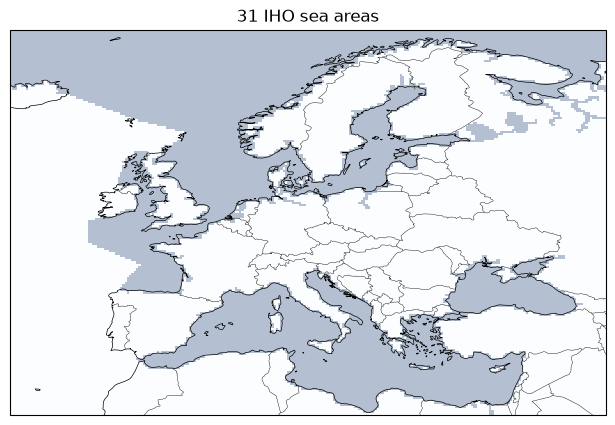

In [104]:
iho_combined_mask = iho_region_masks.any(dim="region")

# Make a simple map of the 31 IHO seas over real coastlines, mirroring the EEA regions map above
figure, axis = plt.subplots(figsize=(8, 5), subplot_kw={"projection": ccrs.PlateCarree()})
axis = cast(GeoAxes, axis)
axis.pcolormesh(
    iho_combined_mask["lon"],
    iho_combined_mask["lat"],
    iho_combined_mask,
    cmap="Blues",
    alpha=0.3,
    transform=ccrs.PlateCarree(),
)
axis.add_feature(cfeature.COASTLINE, linewidth=0.5)
axis.add_feature(cfeature.BORDERS, linewidth=0.3)

# Zoom in on Europe
axis.set_extent([-20, 45, 30, 72], crs=ccrs.PlateCarree())

# Show it
axis.set_title("31 IHO sea areas")
plt.show()

## Analyzing summer anomalies in IHO seas

Now we run the same analysis for each of the smaller seas defined by the IHO, including Bay of Biscay and the English Channel.

In [105]:
# Build one delayed task per date; nothing runs until dask.compute is called.
delayed_iho_regional_means_tasks = [
    dask.delayed(reduce_noaa_regions_date)(dt, iho_region_masks) for dt in FULL_DATE_RANGE
]

# Run the tasks concurrently, threaded so file reads overlap.
with ProgressBar():
    iho_regional_means_list: list[pd.DataFrame] = dask.compute(
        *delayed_iho_regional_means_tasks,
        scheduler="threads",
        num_workers=DASK_WORKERS
    )

[########################################] | 100% Completed | 22m 5ss


Again, we concatenate all of the summer means into a single dataframe. This time there will separate rows for each sea.

In [107]:
iho_regional_means_df = pd.concat(iho_regional_means_list, ignore_index=True)

Again, we write it out to a CSV.

In [108]:
iho_regional_means_df.to_csv(DATA_DIR / "noaa_iho_means.csv", index=False)

Again, we calculate the summer means, using the same function as before.

In [109]:
iho_summer_means = average_summer_months(iho_regional_means_df)

To measure their anomaly from the historic norm, we calculate a 30-year baseline using the period from 1991 to 2020 for each sea individually.

In [110]:
iho_baselines = (
    # First we filter to the climatology period
    iho_summer_means.loc[iho_summer_means["year"].between(CLIMATOLOGY_START_YEAR, CLIMATOLOGY_END_YEAR)]
    # Then we group by sea
    .groupby("region", as_index=False)
    # Then we calculate the mean SST for each sea
    .agg(baseline_c=("mean_sst_c", "mean"))
)

Each year's anomaly from its baseline is calculated.

In [111]:
iho_summer_anomalies = (iho_summer_means.merge(
        # Merge onto the baseline values for each region
        iho_baselines, on="region", validate="many_to_one"
    )
    # Calculate the anomaly by subtracting the baseline from the mean SST
    .assign(anomaly_c=lambda frame: frame["mean_sst_c"] - frame["baseline_c"])
)

And then we calculate further the ranking of each year's anomaly by sea.

In [112]:
iho_summer_rankings = iho_summer_anomalies.assign(
    # Rank within each sea, warmest summer first.
    rank=lambda frame: frame.groupby("region")["anomaly_c"].rank(
        method="min", ascending=False
    # Convert the rank to an integer
    ).astype(int)
)

Now we filter to 2026 to see where this year ranks for each sea.

In [113]:
iho_2026_rankings = (
    # Filter to the year 2026
    iho_summer_rankings.loc[iho_summer_rankings["year"].eq(2026)]
    # Sort by rank so the warmest summer appears first
    .sort_values("rank")
)

Looking at the top 10, we see that Biscay and the Channel rank highly, trailing only a few other regions.

In [115]:
iho_2026_ranking = (
    iho_2026_rankings.set_index("region")
    .head(10)
    [["mean_sst_c", "baseline_c", "anomaly_c", "rank"]]
)

iho_2026_ranking.style.format({
    "mean_sst_c": "{:.1f}",
    "baseline_c": "{:.1f}",
    "anomaly_c": "{:.1f}"
})

,mean_sst_c,baseline_c,anomaly_c,rank
region,,,,
adriatic-sea,26.5,24.1,2.4,1
ionian-sea,26.8,24.6,2.2,1
western-mediterranean,26.0,23.3,2.8,1
mediterranean-sea,26.4,24.4,2.0,1
english-channel,17.8,15.6,2.2,1
irish-sea,15.9,14.2,1.6,1
bristol-channel,18.1,15.8,2.2,1
celtic-sea,17.7,16.0,1.7,1
bay-of-biscay,21.4,19.0,2.4,1


What was the hottest day in the Bay of Biscay? It was August 13 at 23.2°C.

In [118]:
biscay_hottest_days = (
    iho_regional_means_df[iho_regional_means_df.region == 'bay-of-biscay']
        .set_index("date")
        .sort_values(
            "sst_c",
            ascending=False,
        )
        .head()[["sst_c"]]
)

biscay_hottest_days.style.format({
    "sst_c": "{:.1f}"
})

,sst_c
date,
2026-08-13 00:00:00,23.2
2026-08-12 00:00:00,23.2
2026-08-14 00:00:00,23.1
2026-07-18 00:00:00,23.1
2026-07-17 00:00:00,23.0


## Analyzing marine heatwaves

In order to analyze the exceedance days for each IHO sea, we first need to flag the days where the sea surface temperature exceeds the threshold defined by the climatology.

In [119]:
def fit_region_climatology(daily: pd.DataFrame) -> pd.DataFrame:
    """Fit the 1991-2020 climatology and 90th-percentile heatwave threshold for one region, keyed by day of year.

    This is the expensive step (a percentile fit over the full climatology period), so it's cached separately
    from the cheap day-by-day exceedance check below.

    Args:
        daily: pd.DataFrame
            A DataFrame containing daily sea surface temperature data for the region. Must have columns "date" and "sst_c".

    Returns:
        pd.DataFrame
            A DataFrame containing the fitted climatology and heatwave threshold for each day of the year. Columns are "doy", "seasonal_c", and "threshold_c".
    """
    # Assumes daily is already sorted with one row per calendar day, no gaps.
    temperature = (
        # Convert the daily SST data into an xarray DataArray with time as the dimension.
        xr.DataArray(
            daily["sst_c"].to_numpy(),
            coords={"time": daily["date"].to_numpy()},
            dims="time",
            name="sst",
        )
        # Add dummy latitude and longitude dimensions to make the DataArray compatible with xmhw_threshold.
        .expand_dims(lat=[45.0], lon=[-3.0])
        # Transpose the DataArray to have time as the first dimension, followed by latitude and longitude.
        .transpose("time", "lat", "lon")
    )

    # Fit the climatology and heatwave threshold using xmhw_threshold, suppressing warnings and stdout.
    with warnings.catch_warnings(), contextlib.redirect_stdout(io.StringIO()):
        warnings.simplefilter("ignore")
        climatology_raw = xmhw_threshold(
            temperature,
            # Specify the climatology period for the xmhw_threshold function.
            climatologyPeriod=[CLIMATOLOGY_START_YEAR, CLIMATOLOGY_END_YEAR],
            # Skip missing values when fitting the climatology and threshold.
            skipna=True,
            # Beyond that, we accept the defaults, which are:
            # - The default percentile for the heatwave threshold (90th percentile).
            # - The default window length for the running mean (31 days).
        )

    # Reshape xmhw's climatology output into a lookup table keyed by day of year.
    return pd.DataFrame({
        "doy": np.asarray(climatology_raw["thresh"]["doy"], dtype=int),
        "seasonal_c": np.asarray(climatology_raw["seas"].squeeze(), dtype=float),
        "threshold_c": np.asarray(climatology_raw["thresh"].squeeze(), dtype=float),
    })

In [120]:
def flag_region_exceedances(daily: pd.DataFrame, climatology: pd.DataFrame) -> pd.DataFrame:
    """Flag each day that exceeds its region's already-fit day-of-year heatwave threshold.

    Args:
        daily: pd.DataFrame
            A DataFrame containing daily sea surface temperature data for the region. Must have columns "region", "date", and "sst_c".
        climatology: pd.DataFrame
            A DataFrame containing the fitted climatology and heatwave threshold for each day of the year. Must have columns "doy", "seasonal_c", and "threshold_c".

    Returns:
        pd.DataFrame
            A DataFrame containing the original daily data with additional columns "doy", "seasonal_c", "threshold_c", and "exceeds_threshold".
    """
    # Map each date to its corresponding day of year (doy) for merging with the climatology.
    doy_by_date = pd.Series(
        # Convert the dates to day-of-year (doy) using the add_doy function from xarray.
        np.asarray(
            # Create an xarray DataArray from the daily dates to use with add_doy.
            add_doy(
                # Convert the daily dates to an xarray DataArray for use with add_doy.
                xr.DataArray(daily["date"].to_numpy(),
                # Set the dim to "time" for the xarray DataArray.
                dims="time",
                # Set the coordinates for the xarray DataArray.
                coords={"time": daily["date"].to_numpy()}
            )
        )["doy"], dtype=int),
        # Set the index of the Series to the corresponding dates for easy mapping back to the original DataFrame.
        index=pd.DatetimeIndex(daily["date"].to_numpy()),
    )

    # Flag each day that exceeds its region's heatwave threshold by merging with the climatology and comparing SST to the threshold.
    return (
        # Select the relevant columns from the daily DataFrame before merging with the climatology.
        daily[["region", "date", "sst_c"]]
            # Add the day-of-year (doy) column to the daily DataFrame for merging with the climatology.
            .assign(doy=daily["date"].map(doy_by_date))
            # Merge the daily DataFrame with the climatology on the day-of-year (doy) column.
            .merge(climatology, on="doy", how="left", validate="many_to_one")
            # Flag whether each day's SST exceeds the region-specific heatwave threshold.
            .assign(exceeds_threshold=lambda f: f["sst_c"] > f["threshold_c"])
    )

In [121]:
# Build one delayed task per sea; nothing runs until dask.compute is called.
delayed_iho_climatology_tasks = [
    dask.delayed(fit_region_climatology)(group).assign(region=region)
    for region, group in iho_regional_means_df.groupby("region")
]

# Run the tasks concurrently, threaded so each sea's climatology fit overlaps.
with ProgressBar():
    iho_climatology_by_region_list = dask.compute(
        *delayed_iho_climatology_tasks,
        scheduler="threads",
        num_workers=DASK_WORKERS
    )

[########################################] | 100% Completed | 13.07 s


Fit the heatwave climatology once for all 31 IHO seas.

In [122]:
iho_climatology = pd.concat(
    iho_climatology_by_region_list,
    ignore_index=True
)[["region", "doy", "seasonal_c", "threshold_c"]]

In [123]:
# Write it out as a CSV. This is tiny (one row per region per day of year) compared to the daily data.
iho_climatology.to_csv(DATA_DIR / "iho_climatology.csv", index=False)

In [124]:
iho_threshold_days = pd.concat(
    [
        # Flag exceedances for the current region using its climatology
        flag_region_exceedances(group, iho_climatology.loc[iho_climatology["region"].eq(region), ["doy", "seasonal_c", "threshold_c"]])
        for region, group in iho_regional_means_df.groupby("region")
    ],
    ignore_index=True,
)

Pull out the number of heatwave days for the Bay of Biscay and the English Channel.

In [125]:
channel_threshold_days = iho_threshold_days.loc[iho_threshold_days["region"].eq("english-channel")]
biscay_threshold_days = iho_threshold_days.loc[iho_threshold_days["region"].eq("bay-of-biscay")]

Report our findings on heatwave days for Biscay.

In [128]:
biscay_2026_days = biscay_threshold_days.loc[biscay_threshold_days["date"].between("2026-01-01", "2026-08-31")]
biscay_2026_count = int(biscay_2026_days["exceeds_threshold"].sum())  # expect 186

biscay_1980s = biscay_threshold_days.loc[biscay_threshold_days["date"].dt.year.between(1982, 1989)]
biscay_1980s_mean = (
    biscay_1980s.assign(year=biscay_1980s["date"].dt.year)
    .groupby("year")["exceeds_threshold"].sum().mean()
)

print(f"Biscay 2026 heatwave days (Jan-Aug): {biscay_2026_count}")
print(f"Biscay 1980s annual average heatwave days: {biscay_1980s_mean}")

Biscay 2026 heatwave days (Jan-Aug): 186
Biscay 1980s annual average heatwave days: 5.125


Report our findings on heatwave days in the English Channel.

In [131]:
channel_since_2022 = channel_threshold_days.loc[channel_threshold_days["date"].ge("2022-01-01")]
channel_total_days = int(channel_since_2022["exceeds_threshold"].sum())  # expect >900
channel_annual_average = channel_total_days / (channel_since_2022["date"].dt.year.nunique())

print(f"English Channel heatwave days since 2022: {channel_total_days}")
print(f"English Channel heatwave days since 2022 as a percentage: {channel_total_days / len(channel_since_2022) * 100:.2f}%")

English Channel heatwave days since 2022: 902
English Channel heatwave days since 2022 as a percentage: 52.93%


## Verifying the headline claim with ERA5

A cross-check of the "hottest summer on record" finding using the ECMWF ERA5 reanalysis' monthly-mean files, independent of the NOAA OISST record used above.

First we build a mask of the EEA European seas on the ERA5 grid. It doesn't match as cleanly to the npz file, so we use nearest-neighbor interpolation to align the grids.

In [ ]:
with open_era5_month(SUMMER_MONTHS[0]) as era5_sample_ds:
    era5_europe_mask = europe_region_mask.sel(
        lat=xr.DataArray(era5_sample_ds["latitude"].values, dims="latitude"),
        lon=xr.DataArray(era5_sample_ds["longitude"].values, dims="longitude"),
        method="nearest",
    )

In the case of ERA5, we need to consider sea ice and land fractions to determine valid ocean grid cells.

In [133]:
def valid_era5_ocean(
    sst: np.ndarray,
    sea_ice_fraction: np.ndarray,
    land_fraction: np.ndarray,
) -> np.ndarray:
    """Determine which ocean grid cells are ice-free, land-free, and have valid sea-surface temperature.

    Args:
        sst (np.ndarray): Sea-surface temperature array.
        sea_ice_fraction (np.ndarray): Sea-ice concentration array.
        land_fraction (np.ndarray): Land fraction array.

    Returns:
        np.ndarray: Boolean array indicating which grid cells are ice-free, land-free, and have valid sea-surface temperature.
    """
    if len({sst.shape, sea_ice_fraction.shape, land_fraction.shape}) != 1:
        raise ValueError("ERA5 SST, sea ice and land fraction must have the same shape")
    return ~np.isnan(sst) & (sea_ice_fraction < 0.15) & (land_fraction < 0.5)

We craft a similar reduce method for averaging sea-surface temperature over valid ocean grid cells in the ERA5 dataset.

In [134]:
def reduce_era5_regions_month(
    observation_month: datetime,
    region_masks: xr.DataArray,
) -> pd.DataFrame:
    """Reduce ERA5 sea-surface temperature to area-weighted means over valid ocean cells for each region.

    Args:
        observation_month (datetime): The month to process.
        region_masks (xr.DataArray): Boolean masks for each region on the ERA5 grid.

    Returns:
        pd.DataFrame: A DataFrame with columns "region", "month", and "sst_c" containing the area-weighted mean SST for each region.
    """
    # Open the month's ERA5 file (hourly steps across the calendar month).
    with open_era5_month(observation_month) as dataset:
        # Average the hourly steps into one value per grid cell for the month.
        sst_c = dataset["sst"].mean(dim="valid_time") - 273.15
        sea_ice_fraction = dataset["siconc"].mean(dim="valid_time")

        # Land fraction is constant across the month, so just grab the first step.
        land_fraction = dataset["lsm"].isel(valid_time=0)

        # Flag which cells are ice-free, land-free ocean.
        ocean_mask = xr.DataArray(
            valid_era5_ocean(sst_c.values, sea_ice_fraction.values, land_fraction.values),
            coords=sst_c.coords,
            dims=sst_c.dims,
        )

        # Step 1: restrict to the selected region(s).
        region_sst = apply_mask(sst_c, region_masks)

        # Step 2: restrict further to valid ocean cells.
        valid_sst = apply_mask(region_sst, ocean_mask)

        # Step 3: reduce each region to one area-weighted mean.
        means = spatial.reduce(
            valid_sst,
            how="mean",
            weights="latitude",
            mask_dim="region",
        )

    return pd.DataFrame(
        {
            "region": region_masks["region"].values,
            "month": pd.Timestamp(observation_month),
            "sst_c": means.values,
        }
    )

In [135]:
# Build one delayed task per summer month; nothing runs until dask.compute is called.
delayed_era5_monthly_means_tasks = [
    dask.delayed(reduce_era5_regions_month)(month, era5_europe_mask) for month in SUMMER_MONTHS
]

# Run the tasks concurrently, threaded so each month's file read overlaps.
with ProgressBar():
    era5_monthly_means_by_month_list = dask.compute(*delayed_era5_monthly_means_tasks, scheduler="threads", num_workers=DASK_WORKERS)

[########################################] | 100% Completed | 81.24 s


Again, we concatenate the monthly means into a single DataFrame and write it out as a CSV.

In [136]:
era5_monthly_means_df = pd.concat(era5_monthly_means_by_month_list, ignore_index=True)

Again, we write out a CSV.

In [137]:
era5_monthly_means_df.to_csv(DATA_DIR / "era5_monthly_means.csv", index=False)

Again, we average out the summer months of June, July, and August for each year.

In [138]:
era5_summer_means = (
    era5_monthly_means_df.assign(year=era5_monthly_means_df["month"].dt.year)
    .groupby(["region", "year"], as_index=False)
    .agg(
        months=("month", "size"),
        mean_sst_c=("sst_c", "mean"),
    )
)

What was the hottest summer on record, per ERA5? Again, it's 2026.

In [ ]:
era5_summer_ranking = (
    era5_summer_means.set_index("year")
        .sort_values("mean_sst_c", ascending=False)
        [["mean_sst_c"]]
        .head()
)

era5_summer_ranking.style.format(
    {"mean_sst_c": "{:.1f}"}
)

,mean_sst_c
year,
2026,21.6
2025,21.2
2024,21.2
2023,21.2
2022,21.1
